### 1. Get data ready (turn into tensors)
> torchvision.transforms, torch.utils..data.Dataset, torch.utils.data.DataLoader
### 2. Build or pick a pretrained model (to suit your problem)
> 2.1 Pick a loss function and optimizer (torch.optim)

> 2.2 Build a training loop
### 3. Fit the model to the data and make a prediction

### 4. Evaluate the model
> torchmetrics
### 5. Improve through experimentation
> torch.utils.tensorboard
### 6. Save and reload your trained model
> torch.save, torch.load

# We are going to make cnn convolutional neural network (CNN) in this part of course

## 0. Computer vision libraries in pytorch

* `torchvision` - base domain library for pytorch computer vision
* `torchvision.datasets` - get datasets and data loading functions for computer vision here
* `torchvision.models` - get pretrained computer visoin models that you can leverage for your own problems
* `torchvision.transforms` - functions for manipulating your vision data (images) to be suitable for use with an ML model
* `torch.util.data.Dataset` - base dataset class for pytorch
* `torch.utils.data.DataLoader` - Creates a python iterable over a dataset

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import transforms
from torchvision import datasets
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)

2.10.0+cu126
0.25.0+cu126


In [2]:
## 1. Getting a dataset

# The data set we will be using is fashionmnist from torchvision.datasets

In [3]:
#setup training data

from torchvision import datasets
train_data=datasets.FashionMNIST(
    root="data", #Where to download data to?
    train=True, #do we want the training dataset
    download=True, # do we want to download yes or no?
    transform=torchvision.transforms.ToTensor(), # how do we want to transform the data
    target_transform=None # how do we want to transform the labels/target?
)

test_data=datasets.FashionMNIST(
    root="data", train=False, download=True, transform=ToTensor(), target_transform=None
)


In [4]:
len(train_data), len(test_data)

(60000, 10000)

In [5]:
# See the first training example
image, label=train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [6]:
class_names=train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx=train_data.class_to_idx #give dictionary ofdifferent labels on their corresponding index
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [9]:
#Check the shape of our image
print(f"Image shape: {image.shape} -> [colour_channels, height, width]")
print(f"Image label: {class_names[label]}")

Image shape: torch.Size([1, 28, 28]) -> [colour_channels, height, width]
Image label: Ankle boot


## 1.2 Visualizing our data

Image shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, '9')

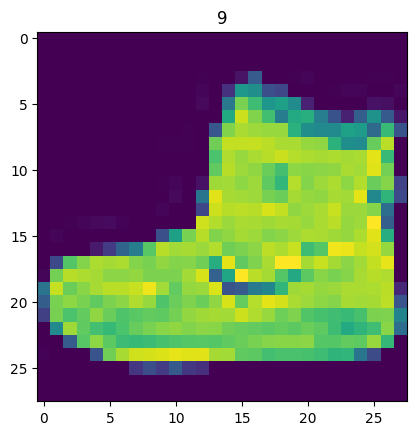

In [10]:
import matplotlib.pyplot as plt
image, label=train_data[0]
print(f"Image shape: {image.shape}")
plt.imshow(image.squeeze()) #.squeeze will remove single dimension from image [1,28,28] tht 1. as plt doesnt expect colour channel and at very least not in beginning
#image
plt.title(label)

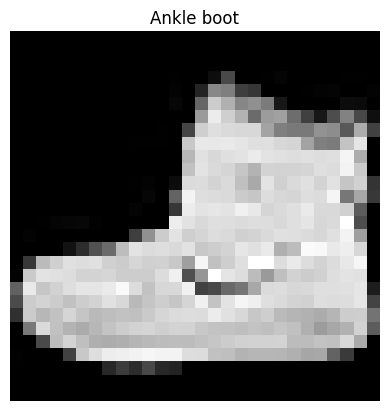

In [11]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label]);
plt.axis("off");

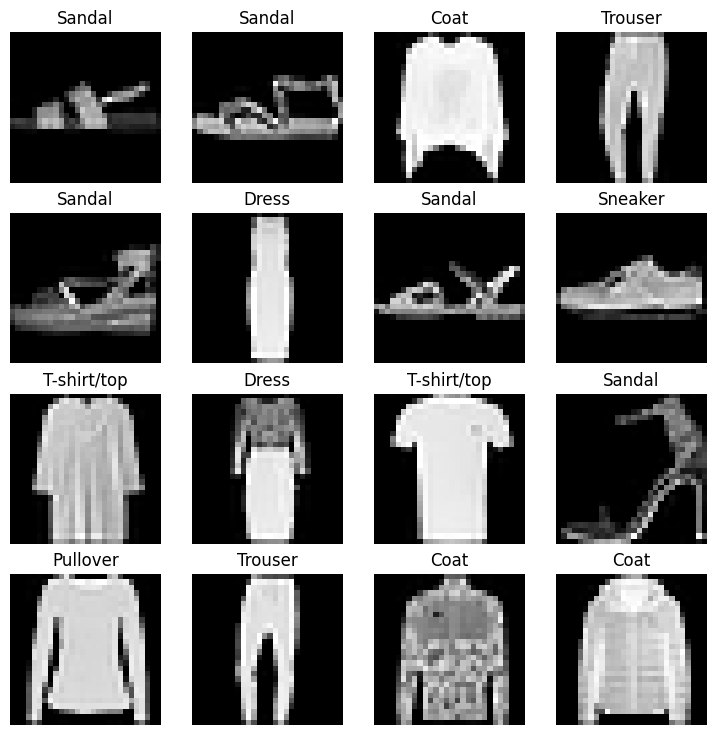

In [22]:
#Plot more images
# torch.manual_seed(2)
fig=plt.figure(figsize=(9,9))
rows, cols=4,4
for i in range(1, rows*cols+1):
    random_idx=torch.randint(0, len(train_data), size=[1]).item()
    img, label=train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off");


In [23]:
train_data, test_data

(Dataset FashionMNIST
     Number of datapoints: 60000
     Root location: data
     Split: Train
     StandardTransform
 Transform: ToTensor(),
 Dataset FashionMNIST
     Number of datapoints: 10000
     Root location: data
     Split: Test
     StandardTransform
 Transform: ToTensor())

## 2. Prepare DataLoader
Right now, our data is in the form of PyTorch Datasets.

DataLoader turns our dataset into a Python iterable.

More specifically, we want to turn our data into batches or mini batches

Why would we do this?

1. It is more computationally efficient, as in your computing hardware may not be able to look (store in memory) at 60000 images in one hit, so we break it down to 32 images at a time (batch size of 32)
2. It gives our neural netowrk more chances to update its gradients per epoch.


In [33]:
from torch.utils.data import DataLoader

#steup the batch size hyper parameter
BATCH_SIZE =32
#Turn datasets into iterable (batches)
train_dataloader=DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader=DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
# we shuffle data in training to remove the order like if initial dataset had tshirt in a line and thn shoes......... thn model might learn the pattern but we dont want it to learn the order so we shuffle it in train_dataloader

#but in test_dataloader for evaluation purpose its generally good to have your test data in the same order because our model will never actually see the test data during training so it doesnt matter

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x21e1b9bda30>,
 <torch.utils.data.dataloader.DataLoader at 0x21e1bb6f790>)

In [34]:
# Let's checkour what we have created
print(f"Dataloaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE} ....")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE} ....")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x0000021E1B9BDA30>, <torch.utils.data.dataloader.DataLoader object at 0x0000021E1BB6F790>)
Length of train_dataloader: 1875 batches of 32 ....
Length of test_dataloader: 313 batches of 32 ....


In [35]:
60000/32


1875.0

In [36]:
10000/32

312.5

In [38]:
#Check out whas inside the training dataloader
train_features_batch, train_labels_batch=next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image shape: torch.Size([1, 28, 28])
Image label: Shirt


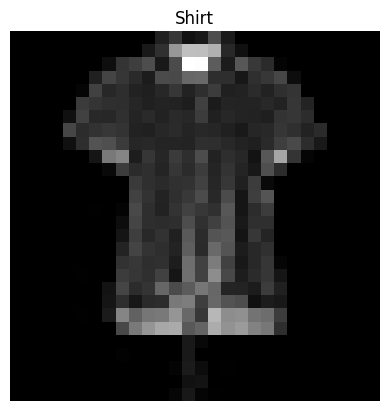

In [64]:
#Show a sample
# torch.manual_seed(42)
random_idx=torch.randint(0, len(train_features_batch), size=[1]).item()
img, label=train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis("off");
print(f"Image shape: {img.shape}")
print(f"Image label: {class_names[label]}")

## 3. Model 0: Build a baseline model

when starting to build a series of machine learning modellng experiments, its best practice to start with a baseline model.

A baseline model is a simple model you will try and improve upon with subsquent models/experiments

In other words: start simply and add complexity when necessary

In [70]:
flatten_model= nn.Flatten()

# Get a single sample
x=train_features_batch[0]
x.shape

#Flatten the sample
output=flatten_model(x)
#print out what happened
print(f"Shape before flattening: {x.shape} -> [colour_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [colour_channels, height*width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [colour_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [colour_channels, height*width]


In [69]:
output #this is a vector

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [80]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
    def __init__(self,
                 input_shape: int,
                 hidden_units: int,
                 output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape)
        )
    def forward(self, x):
        return self.layer_stack(x)

In [83]:
torch.manual_seed(42)

# Setup model with input parameteres
model_0=FashionMNISTModelV0(
    input_shape=28*28, # this is 28*28
    hidden_units=10, #how many units in the hidden layer
    output_shape=len(class_names) # one for every class
).to("cpu")
model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [84]:
dummy_x=torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [85]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

### 3.1 Setup loss, optimizer and evaluation metrics

* Loss function - since we are working with multi class data, our loss functino will be nn.CrossEntropyLoss()
* Optimizer - our optimizer torch.optim.SGD() (stochastic gradient descent)
* Evaluation metric - since we are working on a classification problem, let's use accuracy as our evalutaion metric


In [86]:
import requests
from pathlib import Path

#Download helper function from learn pytorch repo

if Path("helper_functions.py").is_file():
    print("helper function exists, skipping download...")
else:
    print("Downloading helper_functions.py")
    request= requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
    with open("helper_functions.py", "wb") as f:
        f.write(request.content)

E:\AI-ML-Learning\.venv\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [90]:
#Import accuracy metric
from helper_functions import accuracy_fn

#Setup loss function and optimizer
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.SGD(params=model_0.parameters(), lr=0.1)


### 3.2 Creating a function to time our experiments

Machine learning is very experimental.

Two of the main things yo will often want totrack are :
1. Model's performance ( loss and accuracy values etc)
2. How fast it runs

In [92]:
from timeit import default_timer as timer
def print_train_timer(start: float,
                      end: float,
                      device: torch.device=None):
    """Prints difference between start and end times."""
    total_time=end-start
    print(f"Train time on {device}: {total_time:.3f} seconds")
    return total_time

In [93]:
start_time = timer()

#Some code......
end_time=timer()
print_train_timer(start_time,end_time,device="cpu")

Train time on cpu: 0.000 seconds


0.00043849999929079786

### optimizer will update a model's parameters once per batch rather than once per epoch...

## 3.3 Creating a training looop and training a model on batches of data
1. Loop through epochs.
2. loop through training batches, perform training steps, calculate the train loss *per batch*.
3. Loop through testing batches, perform testing steps, calculate the test loss *per batch*
4. Print out what's happening
5. Time it all (for fun)

In [95]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

#Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu=timer()

# Set the number of epochs( we will keep this small for faster training time)
epochs=3

# Create training and test loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch: {epoch}\n--------")
    ### Training
    train_loss=0
    ## Add a loop through the training batches
    for batch, (X, y) in enumerate(train_dataloader):
        model_0.train()
        #1. Forward pass
        y_pred=model_0(X)
        #2. Calculate loss(per batch)
        loss=loss_fn(y_pred, y)
        train_loss+=loss #accumulate train loss
        #3. Optimizer zero grad
        optimizer.zero_grad()
        #4. Loss backward
        loss.backward()
        #5. Optimizer step
        optimizer.step()
        #Print out what's happening
        if batch % 400 ==0:
            print(f"Looked at {batch*len(X)}/{len(train_dataloader.dataset)} samples.")
    # Divide total train loss by length of train dataloader
    train_loss /=len(train_dataloader)

    ### Testing
    test_loss, test_acc=0,0
    model_0.eval()
    with torch.inference_mode():
        for X_test, y_test in test_dataloader:
            # 1.Forward pass
            test_pred=model_0(X_test)
            #2. Calculate loss (accumulatively)
            test_loss+=loss_fn(test_pred, y_test)
            #3. Calculate accuracy
            test_acc+= accuracy_fn(y_true=y_test, y_pred=test_pred.argmax(dim=1))
        #Calculate the test loss average per batch
        test_loss /= len(test_dataloader)
        # Calculate the test acc average per batch
        test_acc/= len(test_dataloader)
    # Print out what's happening
    print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")
#Calculate training time
train_time_end_on_cpu=timer()
total_train_time_model_0=print_train_timer(start=train_time_start_on_cpu,
                                           end=train_time_end_on_cpu,
                                           device=str(next(model_0.parameters())))

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.5904 | Test loss: 0.5095 | Test accuracy: 82.0387
Epoch: 1
--------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4763 | Test loss: 0.4799 | Test accuracy: 83.1969
Epoch: 2
--------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4550 | Test loss: 0.4766 | Test accuracy: 83.4265
Train time on Parameter containing:
tensor([[ 0.0273,  0.0298, -0.0065,  ...,  0.0071,  0.0091,  0.0170],
        [-0.0189, -0.0355,  0.0155,  ...,  0.0161,  0.0120,  0.0117],
        [-0.0008,  0.0020,  0.0032,  ...,  0.0058, -0.0146,  0.0084],
        ...,
        [-0.0116,  0.0274, -0.0323,  ..